In [16]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================

print("\nINICIO DEL ENTORNO DE ANÁLISIS")
print("Se cargan las librerías necesarias para el análisis de datos, visualización y modelado.\n")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report

sns.set(style="whitegrid")

print("Las librerías fueron cargadas correctamente.")


INICIO DEL ENTORNO DE ANÁLISIS
Se cargan las librerías necesarias para el análisis de datos, visualización y modelado.

Las librerías fueron cargadas correctamente.


In [17]:
# ============================================================
# CARGA DEL DATASET
# ============================================================

print("\nCARGA DEL CONJUNTO DE DATOS")

url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv"

df = pd.read_csv(url)

print("\nEl dataset fue cargado correctamente.")
print("Dimensiones del dataset (filas, columnas):", df.shape)

print("\nVista previa de los primeros registros del dataset:\n")
display(df.head())


CARGA DEL CONJUNTO DE DATOS

El dataset fue cargado correctamente.
Dimensiones del dataset (filas, columnas): (344, 8)

Vista previa de los primeros registros del dataset:



,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [18]:
# ============================================================
# EXPLORACIÓN DE LA ESTRUCTURA DEL DATASET
# ============================================================

print("\nANÁLISIS DE LA ESTRUCTURA DE LOS DATOS")

print("\nInformación general de las variables:\n")
df.info()

print("\nResumen estadístico de las variables numéricas:\n")
display(df.describe())


ANÁLISIS DE LA ESTRUCTURA DE LOS DATOS

Información general de las variables:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB

Resumen estadístico de las variables numéricas:



,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000



ANÁLISIS DE DATOS FALTANTES


,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11
year,0


/tmp/ipykernel_169/2251769017.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


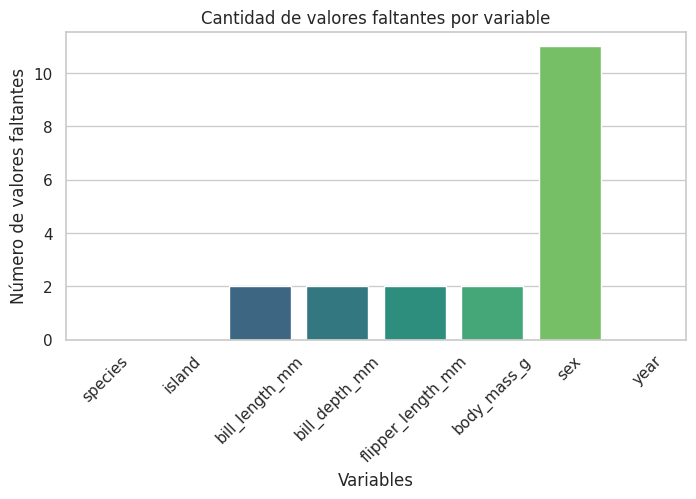

In [19]:
# ============================================================
# ANÁLISIS DE VALORES FALTANTES
# ============================================================

print("\nANÁLISIS DE DATOS FALTANTES")

missing = df.isnull().sum()

display(missing)

plt.figure(figsize=(8,4))

sns.barplot(
    x=missing.index,
    y=missing.values,
    palette="viridis"
)

plt.title("Cantidad de valores faltantes por variable")
plt.ylabel("Número de valores faltantes")
plt.xlabel("Variables")

plt.xticks(rotation=45)

plt.show()

In [20]:
# ============================================================
# LIMPIEZA DE LOS DATOS
# ============================================================

print("\nPROCESO DE LIMPIEZA DEL DATASET")

print("\nSe eliminarán los registros que contienen valores faltantes para facilitar el análisis.")

df = df.dropna()

print("\nNuevo tamaño del dataset:", df.shape)


PROCESO DE LIMPIEZA DEL DATASET

Se eliminarán los registros que contienen valores faltantes para facilitar el análisis.

Nuevo tamaño del dataset: (333, 8)



ANÁLISIS DE DISTRIBUCIÓN DE VARIABLES NUMÉRICAS


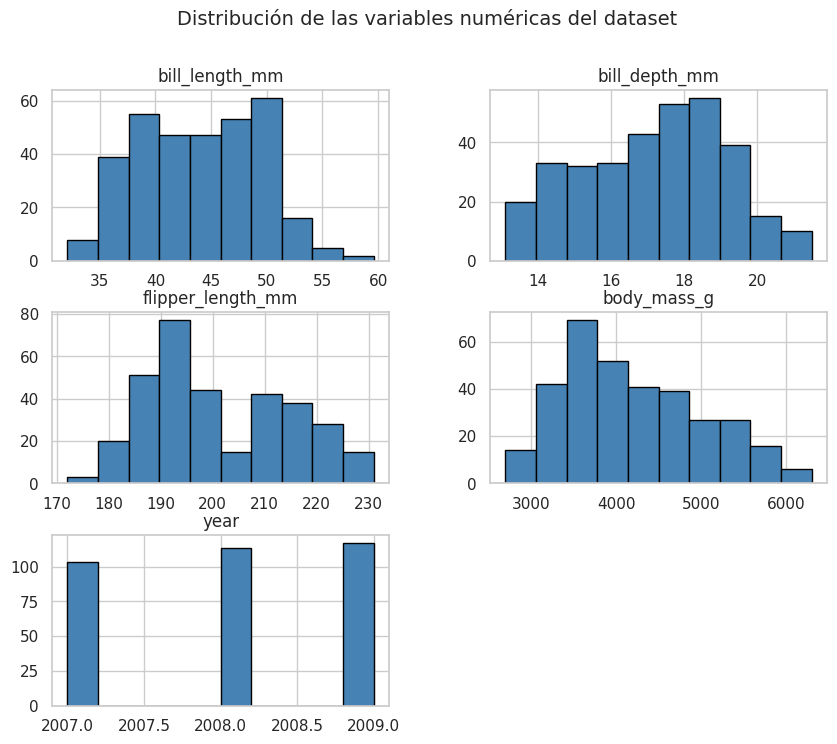

In [21]:
# ============================================================
# DISTRIBUCIÓN DE VARIABLES NUMÉRICAS
# ============================================================

print("\nANÁLISIS DE DISTRIBUCIÓN DE VARIABLES NUMÉRICAS")

variables = df.select_dtypes(include=np.number).columns

df[variables].hist(
    figsize=(10,8),
    color="steelblue",
    edgecolor="black"
)

plt.suptitle("Distribución de las variables numéricas del dataset", fontsize=14)

plt.show()


ANÁLISIS DE LA DISTRIBUCIÓN DE ESPECIES DE PINGÜINOS


/tmp/ipykernel_169/3427123832.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


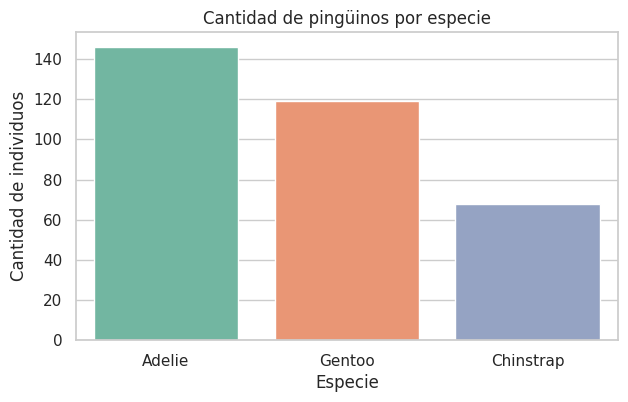

In [23]:
# ============================================================
# DISTRIBUCIÓN DE LAS ESPECIES
# ============================================================

print("\nANÁLISIS DE LA DISTRIBUCIÓN DE ESPECIES DE PINGÜINOS")

plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="species",
    palette="Set2"
)

plt.title("Cantidad de pingüinos por especie")
plt.xlabel("Especie")
plt.ylabel("Cantidad de individuos")

plt.show()


ANÁLISIS DE RELACIÓN ENTRE LA LONGITUD DE LA ALETA Y EL PESO CORPORAL


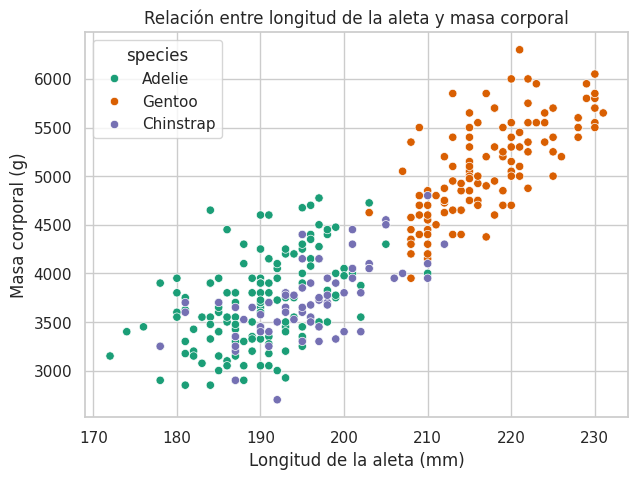

In [24]:
# ============================================================
# RELACIÓN ENTRE VARIABLES MORFOLÓGICAS
# ============================================================

print("\nANÁLISIS DE RELACIÓN ENTRE LA LONGITUD DE LA ALETA Y EL PESO CORPORAL")

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",
    palette="Dark2"
)

plt.title("Relación entre longitud de la aleta y masa corporal")
plt.xlabel("Longitud de la aleta (mm)")
plt.ylabel("Masa corporal (g)")

plt.show()


ANÁLISIS DE CORRELACIÓN ENTRE VARIABLES NUMÉRICAS


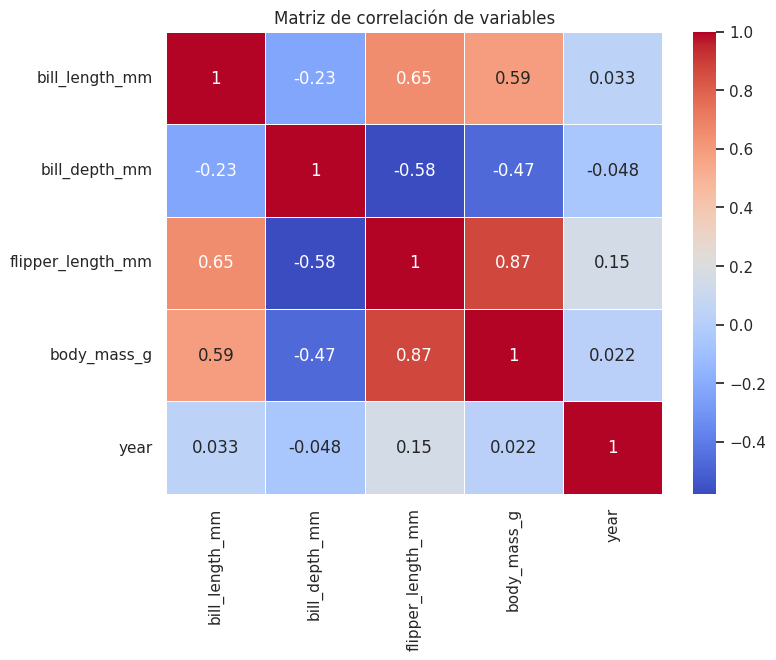

In [25]:
# ============================================================
# MATRIZ DE CORRELACIÓN ENTRE VARIABLES NUMÉRICAS
# ============================================================

print("\nANÁLISIS DE CORRELACIÓN ENTRE VARIABLES NUMÉRICAS")

plt.figure(figsize=(8,6))

correlacion = df.corr(numeric_only=True)

sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matriz de correlación de variables")

plt.show()

In [26]:
# ============================================================
# MODELO DE REGRESIÓN LINEAL
# ============================================================

print("\nMODELO DE REGRESIÓN LINEAL")
print("Objetivo: predecir la masa corporal del pingüino a partir de la longitud de la aleta.\n")

X = df[["flipper_length_mm"]]
y = df["body_mass_g"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

modelo_lineal = LinearRegression()

modelo_lineal.fit(X_train, y_train)

predicciones = modelo_lineal.predict(X_test)

print("Evaluación del modelo:")

print("Error cuadrático medio:", mean_squared_error(y_test, predicciones))
print("Coeficiente de determinación R2:", r2_score(y_test, predicciones))


MODELO DE REGRESIÓN LINEAL
Objetivo: predecir la masa corporal del pingüino a partir de la longitud de la aleta.

Evaluación del modelo:
Error cuadrático medio: 136442.09665293054
Coeficiente de determinación R2: 0.7717862680303836


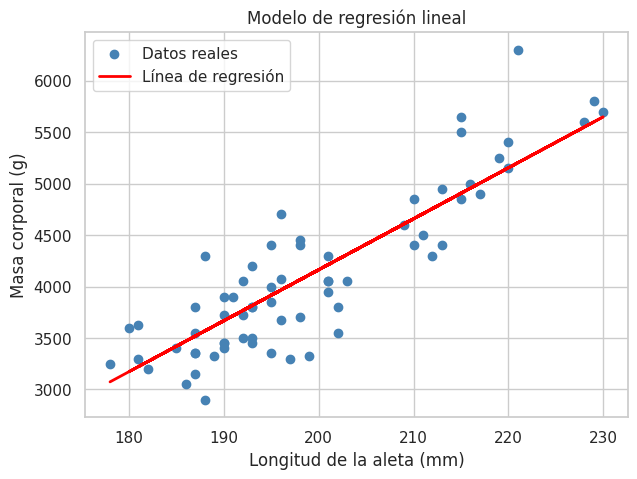

In [27]:
# ============================================================
# VISUALIZACIÓN DEL MODELO DE REGRESIÓN
# ============================================================

plt.figure(figsize=(7,5))

plt.scatter(
    X_test,
    y_test,
    color="steelblue",
    label="Datos reales"
)

plt.plot(
    X_test,
    predicciones,
    color="red",
    linewidth=2,
    label="Línea de regresión"
)

plt.title("Modelo de regresión lineal")
plt.xlabel("Longitud de la aleta (mm)")
plt.ylabel("Masa corporal (g)")

plt.legend()

plt.show()

In [28]:
# ============================================================
# PREPARACIÓN DE DATOS PARA REGRESIÓN LOGÍSTICA
# ============================================================

print("\nPREPARACIÓN DEL MODELO DE CLASIFICACIÓN")

print("Se convertirá la variable 'sex' a formato numérico.")

df["sex"] = df["sex"].map({
    "male":1,
    "female":0
})

X = df[[
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]]

y = df["sex"]


PREPARACIÓN DEL MODELO DE CLASIFICACIÓN
Se convertirá la variable 'sex' a formato numérico.


In [29]:
# ============================================================
# MODELO DE REGRESIÓN LOGÍSTICA
# ============================================================

print("\nMODELO DE CLASIFICACIÓN: REGRESIÓN LOGÍSTICA")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

modelo_logistico = LogisticRegression(max_iter=1000)

modelo_logistico.fit(X_train, y_train)

predicciones = modelo_logistico.predict(X_test)

print("\nPrecisión del modelo:", accuracy_score(y_test, predicciones))

print("\nReporte de clasificación:\n")

print(classification_report(y_test, predicciones))


MODELO DE CLASIFICACIÓN: REGRESIÓN LOGÍSTICA

Precisión del modelo: 0.8955223880597015

Reporte de clasificación:

              precision    recall  f1-score   support

           0       0.94      0.86      0.90        36
           1       0.85      0.94      0.89        31

    accuracy                           0.90        67
   macro avg       0.90      0.90      0.90        67
weighted avg       0.90      0.90      0.90        67



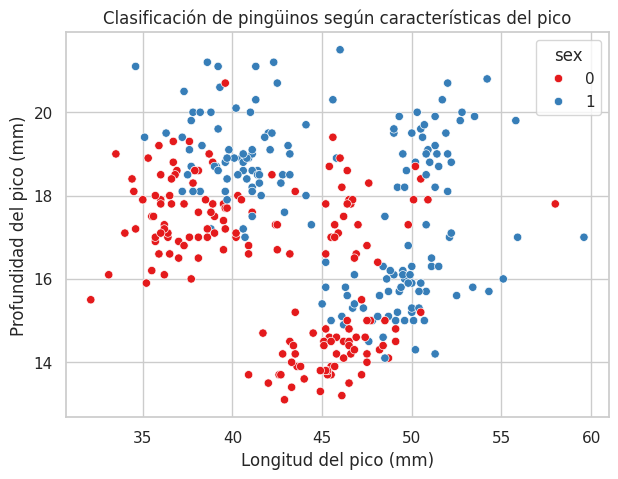

In [30]:
# ============================================================
# VISUALIZACIÓN DE CLASIFICACIÓN
# ============================================================

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="sex",
    palette="Set1"
)

plt.title("Clasificación de pingüinos según características del pico")
plt.xlabel("Longitud del pico (mm)")
plt.ylabel("Profundidad del pico (mm)")

plt.show()